# Assignment Module 2: Aircraft Classification

The goal of this assignment is to implement a neural network that classifies images of 100 aircraft model variants from the [Fine-Grained Visual Classification of Aircraft (**FGVC-Aircraft**) dataset](https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/). The assignment is divided into two parts: first, you will be asked to implement your own neural network for image classification from scratch; then, you will fine-tune a pretrained network provided by PyTorch.

![](https:///raw.githubusercontent.com/CVLAB-Unibo/ipcv-assignment-2/master/fgvc_aircraft_variants.svg)

## Dataset

Download and acces the dataset through its official [PyTorch `FGVCAircraft` class](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html) (by setting its constructor argument `annotation_level` to `'variant'`).

##### Imports + dataset

In [8]:
# set up
from dataclasses import dataclass
import torch
import torch.nn.functional as F
from torch.nn import (
    AdaptiveAvgPool2d,
    BatchNorm2d,
    Conv2d,
    Dropout,
    Linear,
    MaxPool2d,
    Module,
    Parameter,
    ReLU,
    Sequential,
)
from  torchvision.datasets  import FGVCAircraft
from typing import Literal, Optional, Tuple, Union
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
import time
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, OneCycleLR
from torchvision import transforms as T
from torch.optim import Adam

from torchvision.models import ResNet18_Weights, resnet18


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [9]:
# the bottom strip of every image is a copyright banner burned in by the
# dataset authors, not part of the photograph
COPYRIGHT_BAR_PX = 20
# FGVC-Aircraft images aren't all the same resolution, so a resize is
# mandatory just to let the DataLoader stack samples into a batch tensor.
STD_SHAPING = T.Compose([T.Resize((256, 256)), T.ToTensor()])


def _read_lines(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]


def _parse_variant_file(data_dir, split):
    classes = _read_lines(data_dir / "variants.txt")
    class_to_idx = {name: idx for idx, name in enumerate(classes)}

    variant_file = data_dir / f"images_variant_{split}.txt"
    samples = []
    for line in _read_lines(variant_file):
        filename, variant = line.split(" ", 1)
        samples.append((filename, class_to_idx[variant]))
    return samples


class FGVCAircraftDataset(Dataset):
    """FGVC-Aircraft dataset, labeled by variant.

    Each `images_variant_{split}.txt` file already lists exactly the images
    belonging to that split together with their variant label, so it alone
    is enough to recover both the train/val/test membership and the class
    of every image (no need to cross-reference `images_{split}.txt`).
    """

    def __init__(self, root, split="train", transform=None):
        self.transform = (
            STD_SHAPING if transform is None else T.Compose([STD_SHAPING, transform])
        )
        data_dir = Path(root) / "data"

        self.images_dir = data_dir / "images"
        self.samples = _parse_variant_file(data_dir, split)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        filename, label = self.samples[index]
        image_path = self.images_dir / f"{filename}.jpg"

        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        image = image.crop((0, 0, width, height - COPYRIGHT_BAR_PX))

        if self.transform is not None:
            image = self.transform(image)

        return image, label



## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `FGVCAircraft`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~50%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~50% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

##### Network modules: stem layers downsampling -> CNN feature extractor (inception or resnet) -> FC classifier

In [10]:
def _as_hw(size):
    """Helper to map a side length L into the shape tuple (L, L)"""
    return (size, size) if isinstance(size, int) else tuple(size)


class Stem(Module):
    """Resizes the input to a canonical size, then downsamples with
    `conv -> batchnorm -> activation -> maxpool` blocks.

    With the default `canonical_size=256` and three stride-2 poolings,
    output is 256 / 2**3 = 32 pixels per side, at `channels[-1]` channels.
    """

    def __init__(
        self, in_channels=3, canonical_size=256, channels=(32, 64, 128), kernel_size=3
    ):
        super().__init__()
        self.canonical_size = _as_hw(canonical_size)

        kernel_padding = kernel_size // 2
        blocks = []
        prev_channels = in_channels
        for out_channels in channels:
            blocks += [
                Conv2d(
                    prev_channels, out_channels, kernel_size, padding=kernel_padding
                ),
                BatchNorm2d(out_channels),
                ReLU(inplace=True),
                MaxPool2d(2),
            ]
            prev_channels = out_channels
        self.blocks = Sequential(*blocks)

    def forward(self, x):
        x = F.interpolate(
            x, size=self.canonical_size, mode="bilinear", align_corners=False
        )
        return self.blocks(x)


class DropPath(Module):
    """Stochastic depth (Huang et al., 2016): during training, drops the
    entire residual branch for a random subset of samples in the batch,
    scaling survivors by `1 / (1 - drop_prob)` to preserve the expected
    branch magnitude. A no-op at eval time or when `drop_prob == 0.0`."""

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        mask_shape = (x.shape[0],) + (1,) * (x.dim() - 1)
        mask = x.new_empty(mask_shape).bernoulli_(keep_prob)
        return x * mask / keep_prob


class ResidualStage(Module):
    """conv(stride) -> bn -> act -> conv(stride=1) -> bn, added to a 1x1-conv
    shortcut that reshapes the input to the output's shape, then activated."""

    def __init__(
        self, in_channels, out_channels, stride=2, kernel_size=3, stochastic_depth=0.0
    ):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = Conv2d(
            in_channels, out_channels, kernel_size, stride=stride, padding=padding
        )
        self.bn1 = BatchNorm2d(out_channels)
        self.conv2 = Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = BatchNorm2d(out_channels)
        self.shortcut = Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.activation = ReLU(inplace=True)
        self.drop_path = DropPath(stochastic_depth)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.activation(self.bn1(self.conv1(x)))
        out = self.drop_path(self.bn2(self.conv2(out)))

        return self.activation(out + identity)


def _split_channels(total, parts):
    base, remainder = divmod(total, parts)
    return [base + (1 if i < remainder else 0) for i in range(parts)]


class InceptionStage(Module):
    """Four parallel paths (pool, 1x1, 3x3, 5x5) whose outputs are
    concatenated to out_channels, added to a 1x1-conv shortcut that reshapes
    the input to the output's shape, then activated — same contract as
    `ResidualStage`.

    The 3x3 and 5x5 paths are preceded by a 1x1 "reduce" convolution that
    bottlenecks the channel count before the spatially expensive convolution,
    as in GoogLeNet.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=2,
        branch_channels=None,
        reduce_channels=None,
        stochastic_depth=0.0,
    ):
        super().__init__()

        pool_channels, conv1_channels, conv3_channels, conv5_channels = (
            branch_channels or _split_channels(out_channels, 4)
        )
        if reduce_channels is None:
            reduce_channels = max(out_channels // 4, 1)

        self.pool_branch = Sequential(
            MaxPool2d(kernel_size=3, stride=stride, padding=1),
            Conv2d(in_channels, pool_channels, kernel_size=1),
            BatchNorm2d(pool_channels),
            ReLU(inplace=True),
        )
        self.conv1_branch = Sequential(
            Conv2d(in_channels, conv1_channels, kernel_size=1, stride=stride),
            BatchNorm2d(conv1_channels),
            ReLU(inplace=True),
        )
        self.conv3_branch = Sequential(
            Conv2d(in_channels, reduce_channels, kernel_size=1),
            BatchNorm2d(reduce_channels),
            ReLU(inplace=True),
            Conv2d(
                reduce_channels, conv3_channels, kernel_size=3, stride=stride, padding=1
            ),
            BatchNorm2d(conv3_channels),
            ReLU(inplace=True),
        )
        self.conv5_branch = Sequential(
            Conv2d(in_channels, reduce_channels, kernel_size=1),
            BatchNorm2d(reduce_channels),
            ReLU(inplace=True),
            Conv2d(
                reduce_channels, conv5_channels, kernel_size=5, stride=stride, padding=2
            ),
            BatchNorm2d(conv5_channels),
            ReLU(inplace=True),
        )

        self.shortcut = Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.activation = ReLU(inplace=True)
        self.drop_path = DropPath(stochastic_depth)

    def forward(self, x):
        identity = self.shortcut(x)
        branches = [
            self.pool_branch(x),
            self.conv1_branch(x),
            self.conv3_branch(x),
            self.conv5_branch(x),
        ]
        out = self.drop_path(torch.cat(branches, dim=1))
        return self.activation(out + identity)


class FeatureExtractor(Module):
    """Stack of stages (`ResidualStage` by default), each halving feature
    map size while increasing channels. Agnostic to which stage type is
    used, as long as it follows the `(in_channels, out_channels, stride)`
    contract shared by `ResidualStage` and `InceptionStage`.

    With the defaults, an `in_channels=128` input at 32x32 (the Stem's
    default output) becomes 512 channels at 8x8 (32 / 2**2).
    """

    def __init__(
        self,
        in_channels=128,
        stage_channels=(256, 512),
        stride=(2, 2),
        stage_cls=ResidualStage,
        stage_kwargs=None,
    ):
        super().__init__()
        stage_kwargs = stage_kwargs or {}

        if len(stride) != len(stage_channels):
            raise ValueError(
                f"stride tuple length ({len(stride)}) must match "
                f"stage_channels length ({len(stage_channels)})"
            )

        stages = []
        prev_channels = in_channels
        for out_channels, stage_stride in zip(stage_channels, stride):
            stages.append(
                stage_cls(
                    prev_channels, out_channels, stride=stage_stride, **stage_kwargs
                )
            )
            prev_channels = out_channels
        self.stages = Sequential(*stages)

    def forward(self, x):
        return self.stages(x)


class GeMPool(Module):
    def __init__(self, p: float = 3.0, eps: float = 1e-6) -> None:
        super().__init__()
        self.p = Parameter(torch.tensor(p))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        p = self.p.clamp(min=1.0, max=8.0)
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(p), 1).pow(1.0 / p)


class Classifier(Module):
    """Global average pooling into an MLP head. Returns raw logits: pair
    with `nn.CrossEntropyLoss`, which applies log-softmax internally."""

    def __init__(
        self,
        in_channels=512,
        hidden_dim=256,
        num_classes=100,
        pooling: Literal["avg", "gem"] = "avg",
        dropout=0.0,
    ):
        super().__init__()
        # self.pool = AdaptiveAvgPool2d(output_size=1)
        self.pool = AdaptiveAvgPool2d(output_size=1) if pooling == "avg" else GeMPool()
        self.fc1 = Linear(in_channels, hidden_dim)
        self.activation = ReLU(inplace=True)
        self.dropout = Dropout(p=dropout)
        self.fc2 = Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.pool(x).flatten(1)
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


##### Network definition with architecture parameters dataclass

In [11]:
@dataclass
class ExpConfig:
    """Hyperparameters for `Cnn` and its training run. Defaults reproduce the
    module's original, hardcoded defaults, with a `ResidualStage`-based
    feature extractor."""

    in_channels: int = 3
    num_classes: int = 100

    # Stem
    canonical_size: Union[int, Tuple[int, int]] = 256
    stem_channels: Tuple[int, ...] = (32, 64, 128)
    stem_kernel_size: int = 3

    # Feature extractor
    stage_channels: Tuple[int, ...] = (256, 512)
    stage_stride: Tuple[int, ...] = (2, 2)
    block_type: Literal["resnet", "inception"] = "resnet"
    resnet_kernel_size: int = 3
    inception_branch_channels: Optional[Tuple[int, int, int, int]] = None
    inception_reduce_channels: Optional[int] = None

    # Classifier
    pooling: Literal["avg", "gem"] = "avg"
    classifier_hidden_dim: int = 256

    # Regularization
    dropout: float = 0.0
    stochastic_depth: float = 0.0
    label_smoothing: float = 0.0

    # Training
    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    scheduler: Literal["ReduceLROnPlateau","CosineAnnealingLR"] = "CosineAnnealingLR"


class Cnn(Module):
    def __init__(self, config=None):
        super().__init__()
        config = config or ExpConfig()

        self.stem = Stem(
            in_channels=config.in_channels,
            canonical_size=config.canonical_size,
            channels=config.stem_channels,
            kernel_size=config.stem_kernel_size,
        )

        if config.block_type == "resnet":
            stage_cls = ResidualStage
            stage_kwargs = {
                "kernel_size": config.resnet_kernel_size,
                "stochastic_depth": config.stochastic_depth,
            }
        elif config.block_type == "inception":
            stage_cls = InceptionStage
            stage_kwargs = {
                "branch_channels": config.inception_branch_channels,
                "reduce_channels": config.inception_reduce_channels,
                "stochastic_depth": config.stochastic_depth,
            }
        else:
            raise ValueError(f"Unknown block_type: {config.block_type!r}")

        self.feature_extractor = FeatureExtractor(
            in_channels=config.stem_channels[-1],
            stage_channels=config.stage_channels,
            stride=config.stage_stride,
            stage_cls=stage_cls,
            stage_kwargs=stage_kwargs,
        )

        self.classifier = Classifier(
            in_channels=config.stage_channels[-1],
            hidden_dim=config.classifier_hidden_dim,
            num_classes=config.num_classes,
            pooling=config.pooling,
            dropout=config.dropout,
        )

        # Not used by the network itself; exposed so training code can build
        # `nn.CrossEntropyLoss(label_smoothing=model.label_smoothing)`.
        self.label_smoothing = config.label_smoothing

    def forward(self, x):
        x = self.stem(x)
        x = self.feature_extractor(x)
        return self.classifier(x)


##### Training code

In [12]:

def _run_epoch(model, loader, criterion, optimizer=None, device="cuda"):
    model.to(device)
    model.train(optimizer is not None)

    total_loss = 0.0
    correct = 0
    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()

    dataset_size = len(loader.dataset)
    return total_loss / dataset_size, correct / dataset_size


def evaluate(model, ds, transform=None, batch_size=64, device="cuda"):
    """Computes loss and accuracy on the test split"""

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
    )
    criterion = nn.CrossEntropyLoss()
    return _run_epoch(model, loader, criterion, device=device)


def get_scheduler(name: Literal["ReduceLROnPlateau","CosineAnnealingLR"], optimizer, epochs):
    if name == "ReduceLROnPlateau":
        return ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    elif name == "CosineAnnealingLR":
        return CosineAnnealingLR(optimizer, T_max=epochs)
    elif name == "OneCycleLR":
        return OneCycleLR(optimizer, max_lr=[lr_backbone, lr_head],
                        total_steps=steps_per_epoch*num_epochs,
                        pct_start=0.3, div_factor=10, final_div_factor=10000, epochs=num_epochs)
    else:
        return None


def train(
    model,
    train_loader,
    val_loader,
    device,
    config,
    epochs=1,
):
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    optimizer = Adam(
        model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    scheduler = get_scheduler(config.scheduler, optimizer, epochs)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }
    epoch_durations = []

    for epoch in range(epochs):
        start = time.perf_counter()
        train_loss, train_accuracy = _run_epoch(
            model, train_loader, criterion, optimizer=optimizer, device=device
        )
        val_loss, val_accuracy = _run_epoch(model, val_loader, criterion, device=device)
        duration = time.perf_counter() - start
        epoch_durations.append(duration)

        if config.scheduler == "ReduceLROnPlateau":
            scheduler.step(val_loss)
        elif scheduler:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        avg_duration = sum(epoch_durations) / len(epoch_durations)
        eta = avg_duration * (epochs - epoch - 1)
        print(
            f"epoch {epoch + 1}/{epochs} loss={train_loss:.4f} accuracy={train_accuracy:.4f} "
            f"val_loss={val_loss:.4f} val_accuracy={val_accuracy:.4f} "
            f"time={duration:.1f}s eta={eta / 60:.1f}min"
        )

    return model, history


##### CNN training

In [13]:
CANONICAL_SIZE = (256, 256)
AUGMENT_TRANSFORM = T.Compose([
    T.Resize((256, 256)),
    # T.RandomResizedCrop(224, scale=(0.7, 1.0)),   # aircraft can be small in-frame
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    # T.ColorJitter(0.2, 0.2, 0.2),
    T.ToTensor(),
    # T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
BATCH_SIZE = 128


trainset = FGVCAircraft(
    root='./data',
    # split = 'trainval',
    split = 'train',
    annotation_level='variant',
    download=True,
    transform=AUGMENT_TRANSFORM
)
valset = FGVCAircraft(
    root='./data',
    # split = 'test',
    split = 'val',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)

In [ ]:
configs = [
    ("baseline-cosine", ExpConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48, 96, 192), #->4x4
        stage_stride=(2,2,2),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=192,
        label_smoothing=0.1,
        dropout=0.4,
        stochastic_depth=0.0,
        learning_rate=0.005,
        weight_decay=1e-4,
        scheduler="CosineAnnealingLR"
    )),
    ("lower-decay", ExpConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48, 96, 192), #->4x4
        stage_stride=(2,2,2),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=192,
        label_smoothing=0.1,
        dropout=0.4,
        stochastic_depth=0.0,
        learning_rate=0.005,
        weight_decay=5e-5,
        scheduler="ReduceLROnPlateau"
    )),
    ("stoch-again", ExpConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48, 96, 192), #->4x4
        stage_stride=(2,2,2),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=192,
        label_smoothing=0.1,
        dropout=0.4,
        stochastic_depth=0.1,
        learning_rate=0.005,
        weight_decay=1e-4,
        scheduler="ReduceLROnPlateau"
    )),
    ("sizeup", ExpConfig(
        stem_channels=(16, 32, 64), #->32x32
        stage_channels=(64, 128, 256), #->4x4
        stage_stride=(2,2,2),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=256,
        label_smoothing=0.1,
        dropout=0.4,
        stochastic_depth=0.0,
        learning_rate=0.005,
        weight_decay=1e-4,
        scheduler="ReduceLROnPlateau"
    )),
    ("baseline", ExpConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48, 96, 192), #->4x4
        stage_stride=(2,2,2),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=192,
        label_smoothing=0.1,
        dropout=0.4,
        stochastic_depth=0.0,
        learning_rate=0.005,
        weight_decay=1e-4,
        scheduler="ReduceLROnPlateau"
    )),

    # ("stage-pool-sooner", ExpConfig(
    #     stem_channels=(12, 24, 48), #->32x32
    #     stage_channels=(48, 96, 192), #->8x8
    #     stage_stride=(2,2,1),
    #     canonical_size=CANONICAL_SIZE,
    #     block_type="inception",
    #     classifier_hidden_dim=192,
    #     label_smoothing=0.05,
    #     dropout=0.3,
    #     stochastic_depth=0.0,
    #     learning_rate=0.001,
    # )),
]

results = {}

for name, c in configs:
    train_loader = DataLoader(
        dataset=trainset,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        dataset=valset,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    _, history = train(Cnn(c), train_loader, val_loader, epochs=80, config=c, device=DEVICE)
    results[name] = {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
        "val_losses": history["val_loss"],
        "val_accuracy": history["val_accuracy"],
    }

Total parameters: 225,244
epoch 1/80 loss=4.6006 accuracy=0.0123 val_loss=4.5842 val_accuracy=0.0150 time=73.3s eta=96.5min


KeyboardInterrupt: 

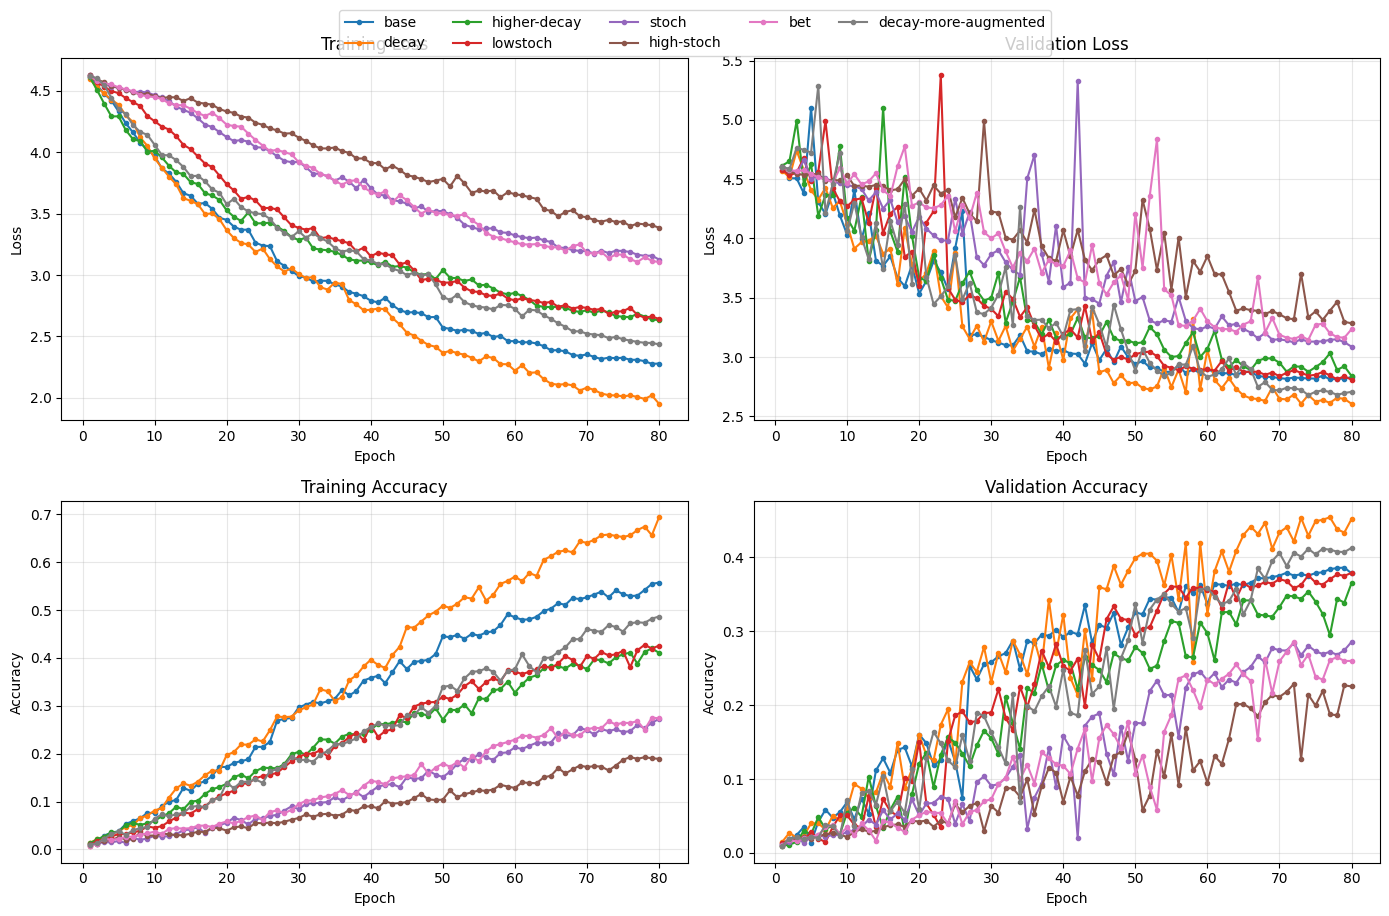

In [ ]:

# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

In [21]:
def train_model(config: ExpConfig, split_validation: bool, epochs: int):
    trainset = FGVCAircraft(
        root='./data',
        split = "train" if split_validation else "trainval",
        annotation_level='variant',
        download=True,
        transform=AUGMENT_TRANSFORM
    )
    valset = FGVCAircraft(
        root='./data',
        # if validation isnt split from train, use test for reporting
        split = 'val' if split_validation else "test",
        annotation_level='variant',
        download=True,
        transform=TRANSFORM
    )
    testset = FGVCAircraft(
        root='./data',
        split = 'test',
        annotation_level='variant',
        download=True,
        transform=TRANSFORM
    )

    trainloader = DataLoader(
        dataset=trainset,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    valloader = DataLoader(
        dataset=valset,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    model, history = train(
        model=Cnn(config),
        train_loader=trainloader,
        val_loader=valloader,
        device=DEVICE,
        epochs=epochs,
        config=config,
    )

    loss, accuracy = evaluate(
        model,
        testset,
        # transform=TRANSFORM,
        batch_size=BATCH_SIZE
    )

    print(f"Final loss {loss}, accuracy {accuracy}")
    # TODO make a proper plot of this
    print(history["val_accuracy"])
    print(history["val_loss"])

    return model, history


def plot_results(history):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    epochs_range = range(1, len(history["train_loss"]) + 1)

    ax_loss.plot(epochs_range, history["train_loss"], label="train")
    ax_loss.plot(epochs_range, history["val_loss"], label="val")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("loss")
    ax_loss.set_title("Loss")
    ax_loss.legend()

    ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
    ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylabel("accuracy")
    ax_acc.set_title("Accuracy")
    ax_acc.legend()

    fig.tight_layout()
    plt.show()

In [9]:

# TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
CONFIG = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 96, 192), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=192,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
)

trainset = FGVCAircraft(
    root='./data',
    split = 'trainval',
    # split = 'train',
    annotation_level='variant',
    download=True,
    transform=AUGMENT_TRANSFORM
)
valset = FGVCAircraft(
    root='./data',
    split = 'val',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
testset = FGVCAircraft(
    root='./data',
    split = 'test',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
print(f"Loaded {len(trainset)} images")
trainloader = DataLoader(
    dataset=trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
valloader = DataLoader(
    # dataset=valset,
    dataset=testset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
# benchmark on the test set each 5 epochs to see the progression on test data
# history, callback = test_performance_callback(1, testset)
model, history = train(
    model=Cnn(CONFIG),
    train_loader=trainloader,
    val_loader=valloader,
    device=DEVICE,
    epochs=100,
    config=CONFIG,
)


loss, accuracy = evaluate(
    model,
    testset,
    # transform=TRANSFORM,
    batch_size=BATCH_SIZE
)

print(f"Final loss {loss}, accuracy {accuracy}")
# TODO make a proper plot of this
print(history["val_accuracy"])
print(history["val_loss"])


Loaded 6667 images
Total parameters: 225,244
epoch 1/100 loss=4.5726 accuracy=0.0139 val_loss=4.4990 val_accuracy=0.0195 time=103.8s eta=171.2min
epoch 2/100 loss=4.4613 accuracy=0.0225 val_loss=4.6832 val_accuracy=0.0150 time=107.3s eta=172.4min
epoch 3/100 loss=4.3047 accuracy=0.0387 val_loss=4.8430 val_accuracy=0.0216 time=104.2s eta=169.9min
epoch 4/100 loss=4.1109 accuracy=0.0543 val_loss=4.0602 val_accuracy=0.0579 time=104.2s eta=167.8min
epoch 5/100 loss=3.9778 accuracy=0.0727 val_loss=4.1053 val_accuracy=0.0651 time=104.0s eta=165.8min
epoch 6/100 loss=3.7973 accuracy=0.0892 val_loss=4.5476 val_accuracy=0.0453 time=103.4s eta=163.7min
epoch 7/100 loss=3.6963 accuracy=0.1119 val_loss=3.9464 val_accuracy=0.0783 time=104.2s eta=161.9min
epoch 8/100 loss=3.5943 accuracy=0.1219 val_loss=3.6591 val_accuracy=0.1326 time=103.2s eta=159.9min
epoch 9/100 loss=3.5134 accuracy=0.1435 val_loss=3.4962 val_accuracy=0.1470 time=103.5s eta=158.1min
epoch 10/100 loss=3.4172 accuracy=0.1666 val_l

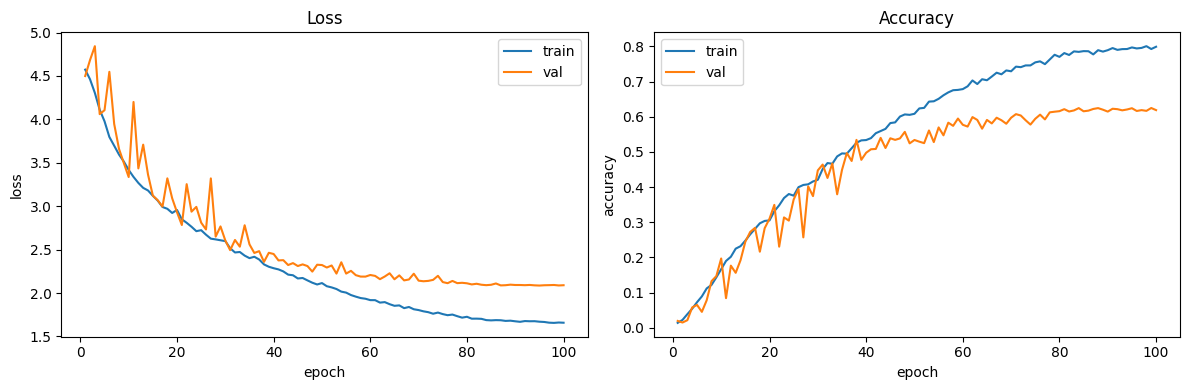

In [10]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

ax_loss.plot(epochs_range, history["train_loss"], label="train")
ax_loss.plot(epochs_range, history["val_loss"], label="val")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("loss")
ax_loss.set_title("Loss")
ax_loss.legend()

ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy")
ax_acc.legend()

fig.tight_layout()
plt.show()


In [14]:

# TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
CONFIG = ExpConfig(
    stem_channels=(16, 32, 64), #->32x32
    stage_channels=(64, 128, 256), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=256,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset = FGVCAircraft(
    root='./data',
    split = 'trainval',
    # split = 'train',
    annotation_level='variant',
    download=True,
    transform=AUGMENT_TRANSFORM
)
valset = FGVCAircraft(
    root='./data',
    split = 'val',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
testset = FGVCAircraft(
    root='./data',
    split = 'test',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
print(f"Loaded {len(trainset)} images")
trainloader = DataLoader(
    dataset=trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
valloader = DataLoader(
    # dataset=valset,
    dataset=testset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
# benchmark on the test set each 5 epochs to see the progression on test data
# history, callback = test_performance_callback(1, testset)
model, history = train(
    model=Cnn(CONFIG),
    train_loader=trainloader,
    val_loader=valloader,
    device=DEVICE,
    epochs=60,
    config=CONFIG,
)


loss, accuracy = evaluate(
    model,
    testset,
    # transform=TRANSFORM,
    batch_size=BATCH_SIZE
)

print(f"Final loss {loss}, accuracy {accuracy}")
# TODO make a proper plot of this
print(history["val_accuracy"])
print(history["val_loss"])


Loaded 6667 images
Total parameters: 390,660
epoch 1/60 loss=4.5723 accuracy=0.0151 val_loss=4.5335 val_accuracy=0.0171 time=108.3s eta=106.5min
epoch 2/60 loss=4.4905 accuracy=0.0196 val_loss=4.4524 val_accuracy=0.0267 time=108.0s eta=104.5min
epoch 3/60 loss=4.4103 accuracy=0.0330 val_loss=4.3388 val_accuracy=0.0345 time=106.8s eta=102.3min
epoch 4/60 loss=4.2230 accuracy=0.0412 val_loss=4.9183 val_accuracy=0.0201 time=109.9s eta=101.0min
epoch 5/60 loss=3.9844 accuracy=0.0661 val_loss=3.9700 val_accuracy=0.0750 time=110.6s eta=99.7min
epoch 6/60 loss=3.8238 accuracy=0.0859 val_loss=4.6553 val_accuracy=0.0270 time=107.5s eta=97.7min
epoch 7/60 loss=3.6998 accuracy=0.1066 val_loss=3.8104 val_accuracy=0.0906 time=105.1s eta=95.4min
epoch 8/60 loss=3.5795 accuracy=0.1320 val_loss=3.9282 val_accuracy=0.0816 time=104.9s eta=93.3min
epoch 9/60 loss=3.4837 accuracy=0.1557 val_loss=4.2358 val_accuracy=0.0666 time=104.2s eta=91.2min
epoch 10/60 loss=3.3658 accuracy=0.1851 val_loss=3.7577 val_

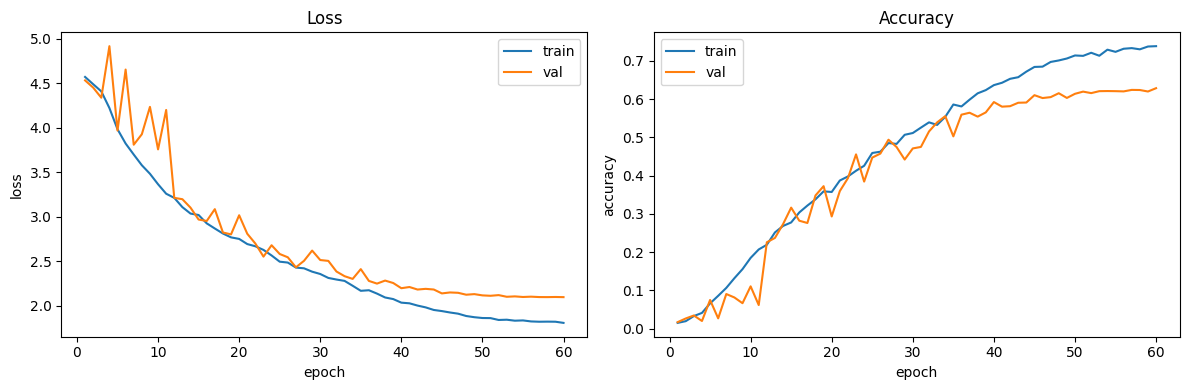

In [15]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

ax_loss.plot(epochs_range, history["train_loss"], label="train")
ax_loss.plot(epochs_range, history["val_loss"], label="val")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("loss")
ax_loss.set_title("Loss")
ax_loss.legend()

ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy")
ax_acc.legend()

fig.tight_layout()
plt.show()


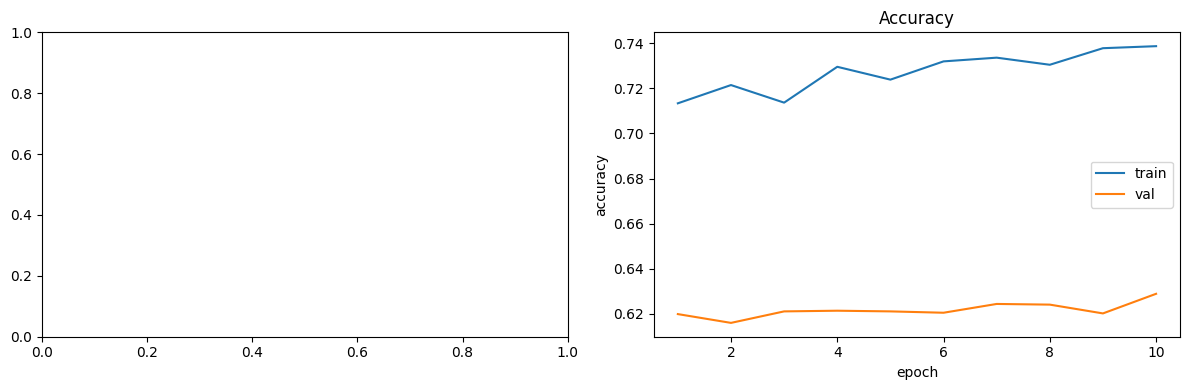

In [19]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history["train_loss"][50:]) + 1)

ax_acc.plot(epochs_range, history["train_accuracy"][50:], label="train")
ax_acc.plot(epochs_range, history["val_accuracy"][50:], label="val")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy")
ax_acc.legend()

fig.tight_layout()
plt.show()


### Ablation

Total parameters: 225,244
epoch 1/1 loss=4.5556 accuracy=0.0175 val_loss=5.1248 val_accuracy=0.0153 time=106.2s eta=0.0min
Final loss 5.124792688142563, accuracy 0.0153015301530153
[0.0153015301530153]
[5.124792572545676]


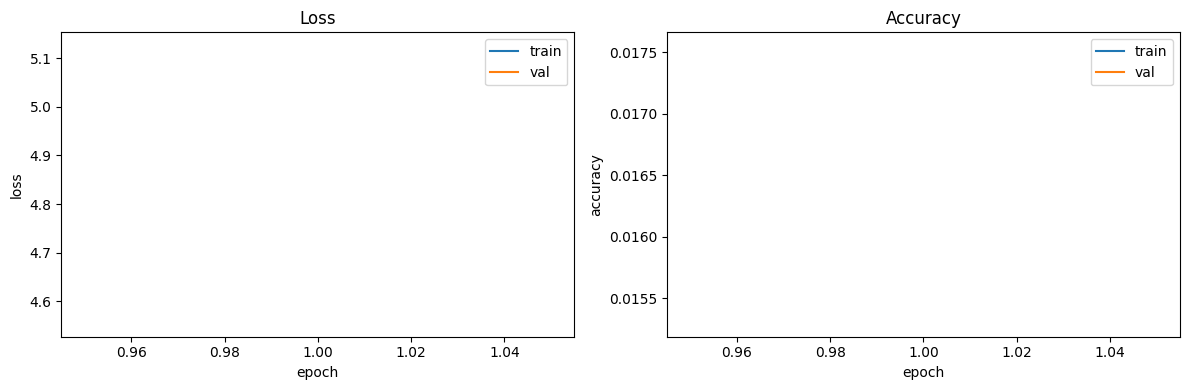

In [22]:
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 96, 192), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=192,
    label_smoothing=0.0,
    dropout=0.0,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=0.0,
)
_, history = train_model(config, split_validation=False, epochs=1)
plot_results(history)

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `FGVCAircraft`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~70%.

In [ ]:
NUM_CLASSES = 100


def build_resnet():
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model

In [ ]:
# TODO: to be filled with hyperparameters from the first experiment once its done
learning_rate = ...
epochs = ...
optimizer = ...
scheduler = ...

resnet = build_resnet()
model, losses, accuracies = train(
    model,
    loader,
    device=DEVICE,
    # training hyperparameters to tweak
    epochs=epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    learning_rate=learning_rate
)

In [ ]:
# TODO: tuning of the hyperparameters, given the baseline at the previous step

resnet = build_resnet()
model, losses, accuracies = train(
    model,
    loader,
    device=DEVICE,
    # training hyperparameters to tweak
    epochs=epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    learning_rate=learning_rate
)